# Notebook 01 — Exploração e Validação do GTIN

**Objetivo:** Testar a hipótese "se o GTIN é informado, está correto".

**Não assumir o GTIN como verdade** — avaliar consistência interna via:
1. Validação de formato (dígito verificador EAN)
2. GTINs internos de balança (prefixo "2")
3. Consistência GTIN × descrição (entropia)
4. Consistência GTIN × NCM (unicidade)
5. Consistência GTIN × preço (coeficiente de variação)

**Saída:** score de confiança por GTIN → separação em `confiavel` / `suspeito`

In [63]:
import warnings
import unicodedata
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy.stats import entropy

warnings.filterwarnings('ignore')

pd.set_option('display.max_colwidth', 80)
pd.set_option('display.float_format', '{:.4f}'.format)

# Separador é espaço; NCM lido como str para preservar zeros à esquerda
df = pd.read_csv(
    './data/WorkshopSampleSEI_utf8.csv',
    sep=' ',
    quotechar='"',
    dtype={'ncm': str, 'gtin': str}
)

# Normalizar NCM para 8 dígitos (preencher zeros à esquerda se necessário)
df['ncm'] = df['ncm'].str.zfill(8)




def normaliza_descricao(texto: str) -> str:
    if not isinstance(texto, str):
        return ''
    # uppercase
    texto = texto.upper()
    # remove acentos
    texto = unicodedata.normalize('NFKD', texto)
    texto = ''.join(c for c in texto if not unicodedata.combining(c))
    # remove caracteres especiais, mantém letras, números e espaço
    texto = re.sub(r'[^A-Z0-9 ]', ' ', texto)
    # colapsa espaços múltiplos
    texto = re.sub(r'\s+', ' ', texto).strip()
    return texto

df['des_item_norm'] = df['des_item'].apply(normaliza_descricao)

# checar resultado
print(df[['des_item', 'des_item_norm']].drop_duplicates().head(10).to_string())


print()

print(f"Shape: {df.shape}")
print(f"Colunas: {df.columns.tolist()}")
df.head(20)


                                        des_item                                 des_item_norm
0                        AGUA MINERAL SGAS 500ML                       AGUA MINERAL SGAS 500ML
1                 #01012900# LING DEFUM SADIA KG                  01012900 LING DEFUM SADIA KG
2                              TAXA DE ENTREGA 1                             TAXA DE ENTREGA 1
3       #01012900# MACARRAO LIANE PAD NOSSO 500G        01012900 MACARRAO LIANE PAD NOSSO 500G
4           ACHOCOLATADO ITALAC 200ML PRONTO LIQ          ACHOCOLATADO ITALAC 200ML PRONTO LIQ
5                CAIPIROSKA SKARLOFF MARACUJA 1L               CAIPIROSKA SKARLOFF MARACUJA 1L
6  CHUVEIRO HERC PLASTICO C/BRACO S/REG. 30CM 08  CHUVEIRO HERC PLASTICO C BRACO S REG 30CM 08
7               SOBRECOXA CONG SADIA BANDEJA 1KG              SOBRECOXA CONG SADIA BANDEJA 1KG
8               MACARRAO INSTATANEO MARATA CARNE              MACARRAO INSTATANEO MARATA CARNE
9              WHISKAS ADULTO CARNE CASTRADOS KG  

,data,des_item,ncm,gtin,unidade,valor_unit_liq,qtd_geral_item,qtd_reg_consolid,des_item_norm
0,2024-08-01,AGUA MINERAL SGAS 500ML,01019000,7896445491076,UND,3.0000,1.0000,1,AGUA MINERAL SGAS 500ML
1,2024-08-01,#01012900# LING DEFUM SADIA KG,01012900,SEM GTIN,KG,29.9800,936.0000,1,01012900 LING DEFUM SADIA KG
2,2024-08-01,TAXA DE ENTREGA 1,01022190,SEM GTIN,UN,7.0000,1.0000,1,TAXA DE ENTREGA 1
3,2024-08-02,#01012900# MACARRAO LIANE PAD NOSSO 500G,01012900,7896080820286,UN,4.1000,1.0000,1,01012900 MACARRAO LIANE PAD NOSSO 500G
4,2024-08-03,ACHOCOLATADO ITALAC 200ML PRONTO LIQ,01012100,7898080640239,UN,1.9900,1.0000,1,ACHOCOLATADO ITALAC 200ML PRONTO LIQ
5,2024-08-03,CAIPIROSKA SKARLOFF MARACUJA 1L,01012100,7896547501079,UN,10.9900,6.0000,1,CAIPIROSKA SKARLOFF MARACUJA 1L
6,2024-11-01,CHUVEIRO HERC PLASTICO C/BRACO S/REG. 30CM 08,01022919,7898668360634,UN,28.0000,1.0000,1,CHUVEIRO HERC PLASTICO C BRACO S REG 30CM 08
7,2024-11-01,SOBRECOXA CONG SADIA BANDEJA 1KG,01012900,7893000436725,UN,14.9900,2.0000,2,SOBRECOXA CONG SADIA BANDEJA 1KG
8,2024-11-04,MACARRAO INSTATANEO MARATA CARNE,01012900,7898617581745,UN,1.4900,4.0000,3,MACARRAO INSTATANEO MARATA CARNE
9,2024-11-05,WHISKAS ADULTO CARNE CASTRADOS KG,01019000,SEM GTIN,UND,20.0000,2.0000,2,WHISKAS ADULTO CARNE CASTRADOS KG


In [64]:
df[df["des_item"].str.contains("agua")]

,data,des_item,ncm,gtin,unidade,valor_unit_liq,qtd_geral_item,qtd_reg_consolid,des_item_norm
666,2024-09-05,agua cgas,01019000,SEM GTIN,UND,3.5000,3.0000,3,AGUA CGAS
1137,2024-06-19,agua mineral com gas,01019000,SEM GTIN,UND,5.0000,3.0000,3,AGUA MINERAL COM GAS
1497,2024-07-05,agua sgas,01019000,SEM GTIN,UND,3.0000,2.0000,2,AGUA SGAS
2488,2024-09-06,agua cgas,01019000,SEM GTIN,UND,3.5000,8.0000,8,AGUA CGAS
4905,2024-10-12,agua mineral com gas,01019000,SEM GTIN,UND,5.0000,1.0000,1,AGUA MINERAL COM GAS
5647,2024-06-01,agua cgas,01019000,SEM GTIN,UND,3.5000,2.0000,2,AGUA CGAS
5905,2024-12-10,agua com gas melene 500ml,01019000,700083273918,UND,3.0000,3.0000,3,AGUA COM GAS MELENE 500ML
7558,2024-12-01,agua mineral com gas,01019000,SEM GTIN,UND,5.0000,5.0000,5,AGUA MINERAL COM GAS
8819,2024-06-04,bomba eletronica para galao de agua,01019000,SEM GTIN,UND,20.0000,1.0000,1,BOMBA ELETRONICA PARA GALAO DE AGUA
10655,2024-12-21,agua mineral com gas,01019000,SEM GTIN,UND,5.0000,3.0000,2,AGUA MINERAL COM GAS


## 1. Visão Geral dos Dados


In [65]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 452257 entries, 0 to 452256
Data columns (total 9 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   data              452257 non-null  str    
 1   des_item          452257 non-null  str    
 2   ncm               452257 non-null  str    
 3   gtin              452257 non-null  str    
 4   unidade           452257 non-null  str    
 5   valor_unit_liq    452257 non-null  float64
 6   qtd_geral_item    452257 non-null  object 
 7   qtd_reg_consolid  452257 non-null  int64  
 8   des_item_norm     452257 non-null  str    
dtypes: float64(1), int64(1), object(1), str(6)
memory usage: 31.1+ MB


In [66]:
df.describe(include='all')


,data,des_item,ncm,gtin,unidade,valor_unit_liq,qtd_geral_item,qtd_reg_consolid,des_item_norm
count,452257,452257,452257,452257,452257,452257.0000,452257.0000,452257.0000,452257
unique,243,229490,1272,48493,747,NaN,33491.0000,NaN,219010
top,2024-12-23,DIVERSOS,16010000,SEM GTIN,UN,NaN,1.0000,NaN,DIVERSOS
freq,2553,1195,21238,200210,206898,NaN,90623.0000,NaN,1220
mean,NaN,NaN,NaN,NaN,NaN,19.0632,NaN,4.0674,NaN
std,NaN,NaN,NaN,NaN,NaN,69.8163,NaN,15.5989,NaN
min,NaN,NaN,NaN,NaN,NaN,0.0000,NaN,1.0000,NaN
25%,NaN,NaN,NaN,NaN,NaN,4.8900,NaN,1.0000,NaN
50%,NaN,NaN,NaN,NaN,NaN,9.9000,NaN,1.0000,NaN
75%,NaN,NaN,NaN,NaN,NaN,23.8900,NaN,3.0000,NaN


## 2. Panorama dos GTINs

Antes de qualquer validação, mapear o que existe no campo `gtin`:
- Ausente / nulo
- String "SEM GTIN" (ou variantes)
- Zeros (`0`, `00000000000000`)
- Valor numérico presente

Apenas GTINs com valor numérico real entram nas análises seguintes.


In [67]:
# Categorizar tipo de GTIN
def classificar_gtin_bruto(g):
    if pd.isna(g):
        return 'nulo'
    g = str(g).strip().upper()
    if g in ('SEM GTIN', 'SEM_GTIN', ''):
        return 'sem_gtin'
    if set(g) <= {'0'}:
        return 'zeros'
    if g.isdigit():
        return 'numerico'
    return 'outro'

df['tipo_gtin'] = df['gtin'].apply(classificar_gtin_bruto)

contagem = df['tipo_gtin'].value_counts()
pct = (contagem / len(df) * 100).round(2)

resumo_gtin = pd.DataFrame({'qtd_linhas': contagem, 'pct': pct})
print(resumo_gtin)


           qtd_linhas     pct
tipo_gtin                    
numerico       252047 55.7300
sem_gtin       200210 44.2700


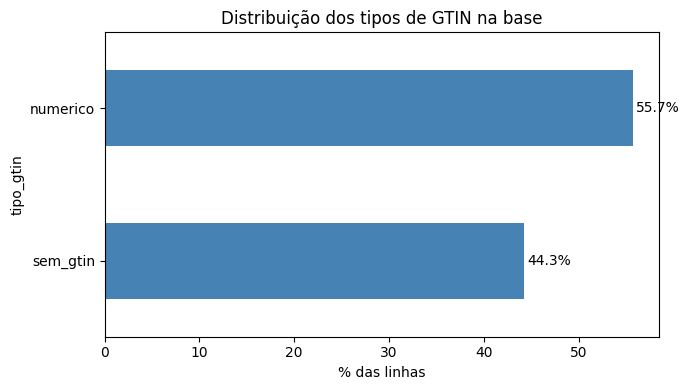

In [68]:
fig, ax = plt.subplots(figsize=(7, 4))
resumo_gtin['pct'].sort_values().plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('% das linhas')
ax.set_title('Distribuição dos tipos de GTIN na base')
for i, v in enumerate(resumo_gtin['pct'].sort_values()):
    ax.text(v + 0.3, i, f'{v:.1f}%', va='center')
plt.tight_layout()
plt.show()


          qtd_linhas     pct
len_gtin                    
0             200210 44.2700
2                375  0.0800
3                947  0.2100
4               1597  0.3500
5                663  0.1500
6                240  0.0500
7                186  0.0400
8               9863  2.1800
9                 10  0.0000
10                 2  0.0000
11               322  0.0700
12              2131  0.4700
13            233033 51.5300
14              2678  0.5900


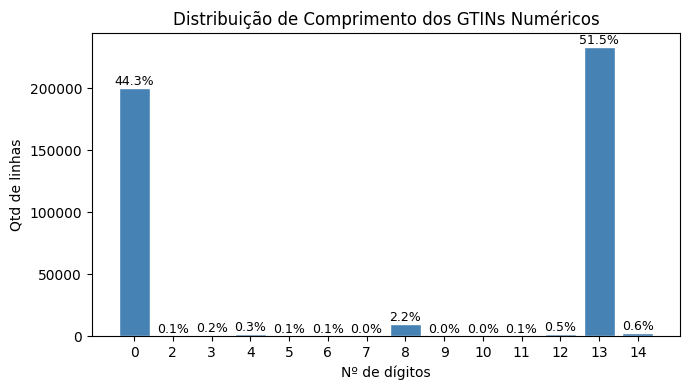

In [69]:
df['len_gtin'] = df['gtin'].apply(
    lambda g: len(g) if str(g).isdigit() else 0
)

contagem_len = df['len_gtin'].value_counts().sort_index()
pct_len = (contagem_len / len(df) * 100).round(2)

resumo_len = pd.DataFrame({'qtd_linhas': contagem_len, 'pct': pct_len})
print(resumo_len)

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(contagem_len.index.astype(str), contagem_len.values, color='steelblue', edgecolor='white')
ax.set_title('Distribuição de Comprimento dos GTINs Numéricos')
ax.set_xlabel('Nº de dígitos')
ax.set_ylabel('Qtd de linhas')
for i, (x, v) in enumerate(zip(contagem_len.index, contagem_len.values)):
    ax.text(i, v + contagem_len.max() * 0.01, f'{pct_len[x]:.1f}%', ha='center', fontsize=9)
plt.tight_layout()
plt.show()


## 3. Validação de Formato — Dígito Verificador EAN

O gráfico mostrou que 52.6% das linhas têm EAN-13 e apenas 2.2% têm EAN-8 — focamos exclusivamente no **EAN-13**.

- **EAN-13** (13 dígitos) — padrão GS1 global, produto embalado

O dígito verificador é calculado por soma ponderada (pesos 1 e 3 alternados, da direita para a esquerda).  
GTIN com dígito errado → provavelmente digitado manualmente ou corrompido.


In [70]:
df = df[df['len_gtin'] == 13].copy()

print(f"Linhas após filtro (apenas EAN-13): {len(df):,}")
print(f"GTINs únicos: {df['gtin'].nunique():,}")


Linhas após filtro (apenas EAN-13): 233,033
GTINs únicos: 42,352


### 3.1 Análise de Prefixos GS1

No padrão GS1, os primeiros 3 dígitos identificam a origem do código:

| Prefixo | Significado |
|---|---|
| `789`, `790` | Brasil (GS1 Brasil) |
| `2xx` | Uso interno / balança (não global) |
| `0xx` | EUA / Canadá (UPC-A com zero à esquerda) |
| Outros | Outros países ou usos especiais |


In [71]:
df['prefixo'] = df['gtin'].str[:3]

top_prefixos = df['prefixo'].value_counts().head(15)
pct_pref = (top_prefixos / len(df) * 100).round(2)

print("=== Top prefixos EAN-13 (3 dígitos) ===")
print("Prefixos distintos:", len(df["prefixo"].unique()))
print(pd.DataFrame({'qtd_linhas': top_prefixos, 'pct': pct_pref}))


=== Top prefixos EAN-13 (3 dígitos) ===
Prefixos distintos: 230
         qtd_linhas     pct
prefixo                    
789          215135 92.3200
762            3816  1.6400
790            2690  1.1500
203            2438  1.0500
290            1611  0.6900
204            1471  0.6300
560             873  0.3700
779             555  0.2400
200             485  0.2100
841             319  0.1400
201             220  0.0900
750             215  0.0900
210             182  0.0800
501             173  0.0700
990             159  0.0700


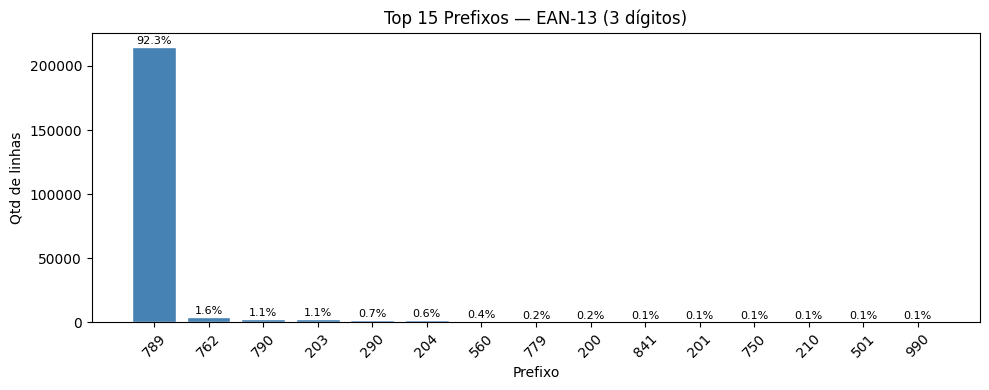

In [72]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(top_prefixos.index, top_prefixos.values, color='steelblue', edgecolor='white')
ax.set_title('Top 15 Prefixos — EAN-13 (3 dígitos)')
ax.set_xlabel('Prefixo')
ax.set_ylabel('Qtd de linhas')
ax.tick_params(axis='x', rotation=45)
for i, (x, v) in enumerate(zip(top_prefixos.index, top_prefixos.values)):
    ax.text(i, v + top_prefixos.max() * 0.01, f'{pct_pref[x]:.1f}%', ha='center', fontsize=8)
plt.tight_layout()
plt.show()


In [73]:
df_13 = df[df['len_gtin'] == 13].copy()
df_789 = df_13[df_13['gtin'].str.startswith('789')].copy()

print(f"EAN-13 total:          {len(df_13):,} linhas | {df_13['gtin'].nunique():,} GTINs únicos")
print(f"EAN-13 prefixo 789:    {len(df_789):,} linhas | {df_789['gtin'].nunique():,} GTINs únicos")
print(f"Cobertura:             {len(df_789)/len(df_13)*100:.1f}%")


EAN-13 total:          233,033 linhas | 42,352 GTINs únicos
EAN-13 prefixo 789:    215,135 linhas | 34,080 GTINs únicos
Cobertura:             92.3%


### 3.2 Validação do Dígito Verificador

Aplicamos o algoritmo EAN-13 padrão GS1 em cada GTIN do grupo 789.  
GTINs com dígito inválido são sinalizados como suspeitos independentemente do conteúdo.


In [74]:
def valida_digito_ean13(gtin: str) -> bool:
    """Retorna True se o dígito verificador do EAN-13 é válido."""
    if not gtin.isdigit() or len(gtin) != 13:
        return False
    pesos = [1 if i % 2 == 0 else 3 for i in range(12)]
    soma = sum(int(d) * p for d, p in zip(gtin[:12], pesos))
    digito_esperado = (10 - (soma % 10)) % 10
    return int(gtin[12]) == digito_esperado

df_789['digito_valido'] = df_789['gtin'].apply(valida_digito_ean13)

total = len(df_789)
validos = df_789['digito_valido'].sum()
invalidos = total - validos

print(f"Dígito válido:    {validos:,}  ({validos/total*100:.1f}%)")
print(f"Dígito inválido:  {invalidos:,}  ({invalidos/total*100:.1f}%)")
print("gtins com prefixo 789 distintos:", df_789['gtin'].nunique())

# Salvar resultados para análise posterior
df_789.to_csv('./data/gtin_789_validacao.csv', columns=[ 'data', 'gtin', 'ncm', 'des_item_norm', 'unidade', 'valor_unit_liq', 'qtd_geral_item', 'qtd_reg_consolid' ])

Dígito válido:    215,135  (100.0%)
Dígito inválido:  0  (0.0%)
gtins com prefixo 789 distintos: 34080


## 4. Consistência GTIN × Descrição

Um GTIN confiável deve sempre se referir ao mesmo produto — logo as descrições associadas a ele devem ser variações mínimas do mesmo texto.  
Medimos `n_desc_unicas` por GTIN: valores altos indicam reutilização indevida do código.



GTINs com 1 descrição única:   19,141
GTINs com 2-5 descrições:      9,892
GTINs com >5 descrições:       5,047


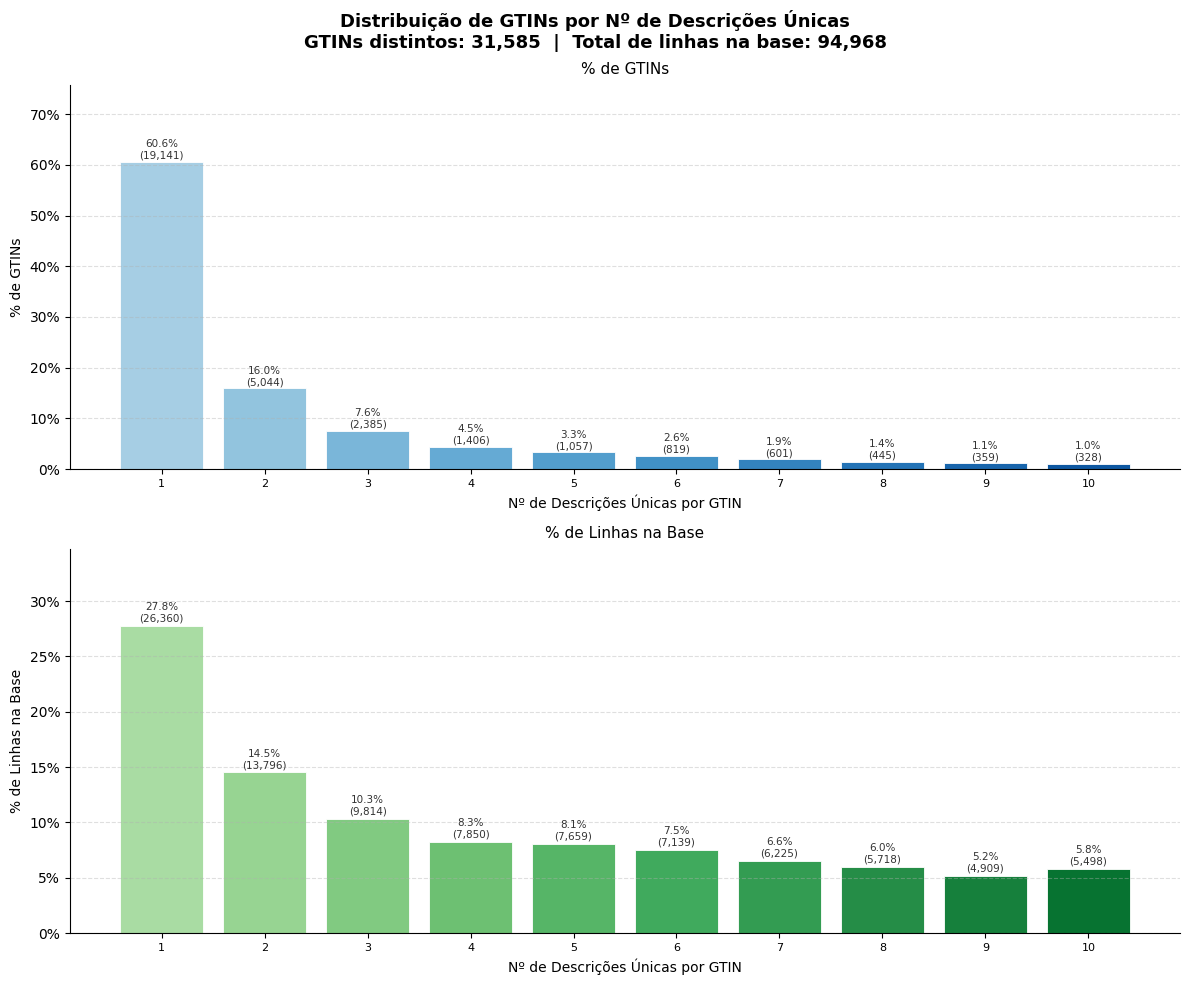

In [94]:
desc_por_gtin = df_789.groupby('gtin').agg(
    n_desc_unicas=('des_item_norm', 'nunique'),
    n_registros=('des_item_norm', 'count')
).reset_index()

print(f"\nGTINs com 1 descrição única:   {(desc_por_gtin['n_desc_unicas'] == 1).sum():,}")
print(f"GTINs com 2-5 descrições:      {desc_por_gtin['n_desc_unicas'].between(2,5).sum():,}")
print(f"GTINs com >5 descrições:       {(desc_por_gtin['n_desc_unicas'] > 5).sum():,}")


agrupado = desc_por_gtin.groupby('n_desc_unicas').agg(
    n_gtins=('gtin', 'count'),
    n_linhas=('n_registros', 'sum')
).reset_index()

agrupado = agrupado[agrupado['n_desc_unicas'] <= 10].copy()
total_gtins  = agrupado['n_gtins'].sum()
total_linhas = agrupado['n_linhas'].sum()

agrupado['pct_gtins']  = agrupado['n_gtins']  / total_gtins  * 100
agrupado['pct_linhas'] = agrupado['n_linhas'] / total_linhas * 100

x      = agrupado['n_desc_unicas'].astype(str)
x_pos  = np.arange(len(x))
cores  = plt.cm.Blues(np.linspace(0.35, 0.85, len(agrupado)))

# --- Plot ---
fig, axes = plt.subplots(2, 1, figsize=(max(12, len(agrupado) * 0.6), 10))
fig.suptitle(
    f'Distribuição de GTINs por Nº de Descrições Únicas\n'
    f'GTINs distintos: {total_gtins:,}  |  Total de linhas na base: {total_linhas:,}',
    fontsize=13, fontweight='bold'
)

for ax, col_pct, col_abs, titulo, cor in zip(
    axes,
    ['pct_gtins',  'pct_linhas'],
    ['n_gtins',    'n_linhas'],
    ['% de GTINs', '% de Linhas na Base'],
    [plt.cm.Blues, plt.cm.Greens]
):
    cores_ax = cor(np.linspace(0.35, 0.85, len(agrupado)))
    bars = ax.bar(x_pos, agrupado[col_pct], color=cores_ax, edgecolor='white', linewidth=0.6)

    for bar, pct, abs_val in zip(bars, agrupado[col_pct], agrupado[col_abs]):
        if pct >= 1.0:   # só anota barras com pelo menos 1% para não poluir
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.2,
                f'{pct:.1f}%\n({abs_val:,.0f})',
                ha='center', va='bottom', fontsize=7.5, color='#333333'
            )

    ax.set_xticks(x_pos)
    ax.set_xticklabels(x, rotation=45 if len(x) > 15 else 0, fontsize=8)
    ax.set_xlabel('Nº de Descrições Únicas por GTIN', fontsize=10)
    ax.set_ylabel(titulo, fontsize=10)
    ax.set_ylim(0, agrupado[col_pct].max() * 1.25)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    ax.set_title(titulo, fontsize=11, pad=8)

plt.tight_layout()
plt.savefig('distribuicao_gtins_descricoes_completa.png', dpi=150, bbox_inches='tight')
plt.show()



## 5. Consistência GTIN × NCM

Fiscalmente, um GTIN está vinculado a um produto específico — logo deve ter um único NCM.  
Múltiplos NCMs para o mesmo GTIN é forte sinal de erro de registro.


In [76]:
ncm_por_gtin = df_789.groupby('gtin').agg(
    n_ncm_unicos=('ncm', 'nunique'),
    ncms=('ncm', lambda x: list(x.unique()))
).reset_index()

print(ncm_por_gtin['n_ncm_unicos'].describe())
print(f"\nGTINs com 1 NCM único:    {(ncm_por_gtin['n_ncm_unicos'] == 1).sum():,}")
print(f"GTINs com 2+ NCMs:        {(ncm_por_gtin['n_ncm_unicos'] > 1).sum():,}")


count   34080.0000
mean        1.6179
std         1.6044
min         1.0000
25%         1.0000
50%         1.0000
75%         2.0000
max        35.0000
Name: n_ncm_unicos, dtype: float64

GTINs com 1 NCM único:    24,847
GTINs com 2+ NCMs:        9,233


## 6. Consistência GTIN × Preço

Variação de preço extrema num mesmo GTIN pode indicar produtos distintos sendo registrados com o mesmo código.  
Usamos o **coeficiente de variação** (CV = std / mean) como métrica — um CV alto merece atenção.  
Variação legítima existe (região, promoção), então calibramos o threshold com o próprio dado.


In [77]:
preco_por_gtin = df_789.groupby('gtin').agg(
    preco_medio=('valor_unit_liq', 'mean'),
    preco_std=('valor_unit_liq', 'std'),
    preco_min=('valor_unit_liq', 'min'),
    preco_max=('valor_unit_liq', 'max'),
    n_registros=('valor_unit_liq', 'count')
).reset_index()

preco_por_gtin['cv'] = preco_por_gtin['preco_std'] / preco_por_gtin['preco_medio']
preco_por_gtin['cv'] = preco_por_gtin['cv'].fillna(0)

print(preco_por_gtin['cv'].describe())
print(f"\nGTINs com CV < 0.3  (preço estável):    {(preco_por_gtin['cv'] < 0.3).sum():,}")
print(f"GTINs com CV 0.3-1  (variação moderada): {preco_por_gtin['cv'].between(0.3, 1).sum():,}")
print(f"GTINs com CV > 1    (variação extrema):  {(preco_por_gtin['cv'] > 1).sum():,}")


count   34080.0000
mean        0.0910
std         0.1883
min         0.0000
25%         0.0000
50%         0.0000
75%         0.1303
max         5.9990
Name: cv, dtype: float64

GTINs com CV < 0.3  (preço estável):    32,125
GTINs com CV 0.3-1  (variação moderada): 1,653
GTINs com CV > 1    (variação extrema):  302


## 7. Score de Confiança por GTIN

Combinamos todos os sinais num score único. Cada critério contribui com uma penalidade:

| Critério | Condição | Penalidade |
|---|---|---|
| Dígito verificador | inválido | 0.40 |
| Múltiplos NCMs | n_ncm > 1 | 0.30 |
| Muitas descrições | n_desc > 5 | 0.20 |
| Preço muito variável | CV > 1 | 0.10 |

`confianca = 1 - soma_penalidades` (mínimo 0)  
GTINs com `confianca >= 0.7` → **confiável** | abaixo → **suspeito**


In [78]:
digito_por_gtin = df_789.groupby('gtin')['digito_valido'].all().reset_index()
digito_por_gtin.columns = ['gtin', 'digito_valido']

df_gtin_score = (
    desc_por_gtin
    .merge(ncm_por_gtin[['gtin', 'n_ncm_unicos']], on='gtin')
    .merge(preco_por_gtin[['gtin', 'cv']], on='gtin')
    .merge(digito_por_gtin, on='gtin')
)

def calcular_score(row):
    penalidade = 0
    if not row['digito_valido']:   penalidade += 0.40
    if row['n_ncm_unicos'] > 1:    penalidade += 0.30
    if row['n_desc_unicas'] > 5:   penalidade += 0.20
    if row['cv'] > 1:              penalidade += 0.10
    return max(0, 1 - penalidade)

df_gtin_score['confianca'] = df_gtin_score.apply(calcular_score, axis=1)
df_gtin_score['status'] = df_gtin_score['confianca'].apply(
    lambda x: 'confiavel' if x >= 0.7 else 'suspeito'
)

print(df_gtin_score['status'].value_counts())
print(f"\nCobertura confiável: {(df_gtin_score['status']=='confiavel').sum() / len(df_gtin_score)*100:.1f}% dos GTINs únicos")


status
confiavel    29848
suspeito      4232
Name: count, dtype: int64

Cobertura confiável: 87.6% dos GTINs únicos


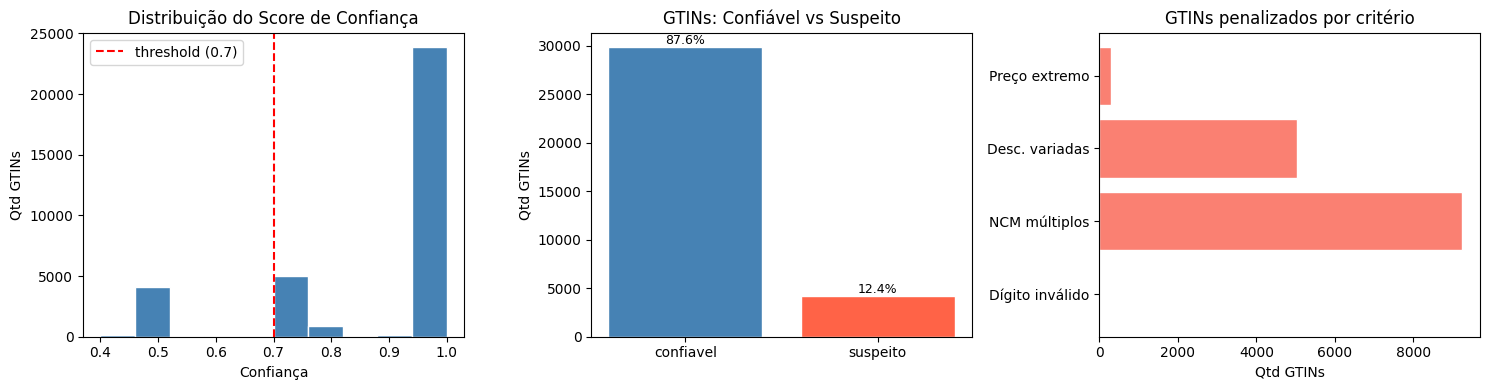

In [79]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Distribuição do score
axes[0].hist(df_gtin_score['confianca'], bins=10, color='steelblue', edgecolor='white')
axes[0].axvline(0.7, color='red', linestyle='--', label='threshold (0.7)')
axes[0].set_title('Distribuição do Score de Confiança')
axes[0].set_xlabel('Confiança')
axes[0].set_ylabel('Qtd GTINs')
axes[0].legend()

# Status
contagem_status = df_gtin_score['status'].value_counts()
axes[1].bar(contagem_status.index, contagem_status.values,
            color=['steelblue', 'tomato'], edgecolor='white')
axes[1].set_title('GTINs: Confiável vs Suspeito')
axes[1].set_ylabel('Qtd GTINs')
for i, (x, v) in enumerate(zip(contagem_status.index, contagem_status.values)):
    axes[1].text(i, v + contagem_status.max()*0.01,
                 f'{v/len(df_gtin_score)*100:.1f}%', ha='center', fontsize=9)

# Penalidades — quantos GTINs foram penalizados por cada critério
criterios = {
    'Dígito inválido': (~df_gtin_score['digito_valido']).sum(),
    'NCM múltiplos':   (df_gtin_score['n_ncm_unicos'] > 1).sum(),
    'Desc. variadas':  (df_gtin_score['n_desc_unicas'] > 5).sum(),
    'Preço extremo':   (df_gtin_score['cv'] > 1).sum(),
}
axes[2].barh(list(criterios.keys()), list(criterios.values()), color='salmon', edgecolor='white')
axes[2].set_title('GTINs penalizados por critério')
axes[2].set_xlabel('Qtd GTINs')

plt.tight_layout()
plt.show()


In [80]:
df_789

,data,des_item,ncm,gtin,unidade,valor_unit_liq,qtd_geral_item,qtd_reg_consolid,des_item_norm,tipo_gtin,len_gtin,prefixo,digito_valido
0,2024-08-01,AGUA MINERAL SGAS 500ML,01019000,7896445491076,UND,3.0000,1.0000,1,AGUA MINERAL SGAS 500ML,numerico,13,789,True
3,2024-08-02,#01012900# MACARRAO LIANE PAD NOSSO 500G,01012900,7896080820286,UN,4.1000,1.0000,1,01012900 MACARRAO LIANE PAD NOSSO 500G,numerico,13,789,True
4,2024-08-03,ACHOCOLATADO ITALAC 200ML PRONTO LIQ,01012100,7898080640239,UN,1.9900,1.0000,1,ACHOCOLATADO ITALAC 200ML PRONTO LIQ,numerico,13,789,True
5,2024-08-03,CAIPIROSKA SKARLOFF MARACUJA 1L,01012100,7896547501079,UN,10.9900,6.0000,1,CAIPIROSKA SKARLOFF MARACUJA 1L,numerico,13,789,True
6,2024-11-01,CHUVEIRO HERC PLASTICO C/BRACO S/REG. 30CM 08,01022919,7898668360634,UN,28.0000,1.0000,1,CHUVEIRO HERC PLASTICO C BRACO S REG 30CM 08,numerico,13,789,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
452218,2024-05-06,OLEO HIDRA POTEN 1L,27101932,7898344111253,Un,29.9000,1.0000,1,OLEO HIDRA POTEN 1L,numerico,13,789,True
452219,2024-05-06,LUBRAX ESSENCIAL SL 20W50 1 LT,27101932,7891344013886,UN,34.0000,6.0000,6,LUBRAX ESSENCIAL SL 20W50 1 LT,numerico,13,789,True
452223,2024-05-07,OLEO PEROBA 100 ML,27101999,7896050502204,UN,10.9900,1.0000,1,OLEO PEROBA 100 ML,numerico,13,789,True
452243,2024-07-28,OL PEROBA 100ML LAV,27101999,7896050502204,Un,8.8900,4.0000,4,OL PEROBA 100ML LAV,numerico,13,789,True


In [81]:
df_gtin_score

,gtin,n_desc_unicas,n_registros,n_ncm_unicos,cv,digito_valido,confianca,status
0,7890000000000,2,2,2,0.3451,True,0.7000,confiavel
1,7890000000017,5,6,5,1.3960,True,0.6000,suspeito
2,7890000000024,3,3,3,0.7920,True,0.7000,confiavel
3,7890000000048,1,1,1,0.0000,True,1.0000,confiavel
4,7890000000062,2,4,2,0.6133,True,0.7000,confiavel
...,...,...,...,...,...,...,...,...
34075,7899990400203,5,5,1,0.2020,True,1.0000,confiavel
34076,7899994899461,1,1,1,0.0000,True,1.0000,confiavel
34077,7899997012980,1,1,1,0.0000,True,1.0000,confiavel
34078,7899999900407,1,1,1,0.0000,True,1.0000,confiavel


In [82]:
df_789[df_789['gtin'] == '7898080640239'][['des_item', 'ncm']].head(30)

,des_item,ncm
4,ACHOCOLATADO ITALAC 200ML PRONTO LIQ,01012100
1141,ACHOC NATURAL ITALAKINHO CHOCOLATE LIQ. 200ML,01059900
1218,BEBIDA LAC. ACHOCOLATADO 200 ML ITALAKINHO,01042090
3422,ACHOCOLATADO ITALAC 200ML PRONTO LIQ,01012100
9383,ACHOCOLATADO ITALAC 200ML PRONTO LIQ,01012100
10664,ACHOCOLATADO ITALAC 200ML PRONTO LIQ,01012100
13769,ACHOCOLATADO ITALAC 200ML PRONTO LIQ,01012100
15636,ACHOCOLATADO ITALAC 200ML PRONTO LIQ,01012100
19127,BEBIDA LAC. ACHOCOLATADO 200 ML ITALAKINHO,01042090
22282,ACHOC. ITALAKINHO 200ML,01012100


## 4.1 Frequência e Representatividade dos GTINs

Antes de analisar consistência, entendemos a concentração: quantos GTINs cobrem a maior parte da base?  
Isso informa o impacto real do dicionário GTIN — se poucos GTINs cobrem 80% das linhas, o ganho é enorme.


In [83]:
df_789['gtin'] = df_789['gtin'].astype(str).str.zfill(13)
df_789['qtd_geral_item'] = pd.to_numeric(df_789['qtd_geral_item'], errors='coerce')
df_789['valor_unit_liq'] = pd.to_numeric(df_789['valor_unit_liq'], errors='coerce')

freq_gtin = df_789.groupby('gtin').agg(
    n_linhas        = pd.NamedAgg(column='des_item',       aggfunc='count'),
    qtd_vendida     = pd.NamedAgg(column='qtd_geral_item', aggfunc='sum'),
    n_desc_unicas   = pd.NamedAgg(column='des_item_norm',  aggfunc='nunique'),
    preco_medio     = pd.NamedAgg(column='valor_unit_liq', aggfunc='mean'),
).sort_values('n_linhas', ascending=False).reset_index()

freq_gtin['valor_total'] = freq_gtin['qtd_vendida'] * freq_gtin['preco_medio']

total_linhas = len(df_789)
freq_gtin['pct_linhas']    = freq_gtin['n_linhas'] / total_linhas * 100
freq_gtin['pct_acumulada'] = freq_gtin['pct_linhas'].cumsum()

print(f"Total de GTINs únicos: {len(freq_gtin):,}")
print(freq_gtin.head(10).to_string(index=False))


Total de GTINs únicos: 34,080
         gtin  n_linhas  qtd_vendida  n_desc_unicas  preco_medio  valor_total  pct_linhas  pct_acumulada
7891107101621       811   21933.0000            132       8.1130  177941.5365      0.3770         0.3770
7894904255030       722   12520.0000             93      38.6865  484354.5812      0.3356         0.7126
7893000979932       664    8042.0000            137       3.3291   26772.4720      0.3086         1.0212
7898929966056       626   16167.0000            167       8.3835  135535.5022      0.2910         1.3122
7898080640413       606    8044.0000            174       6.7971   54675.8379      0.2817         1.5939
7898932426042       547   22744.0000             83       2.0285   46135.8090      0.2543         1.8481
7896481130137       523   16076.2000             97       2.6574   42721.1951      0.2431         2.0912
7898080640222       517    4441.0000            127       3.8891   17271.6245      0.2403         2.3316
7893000980006       483  

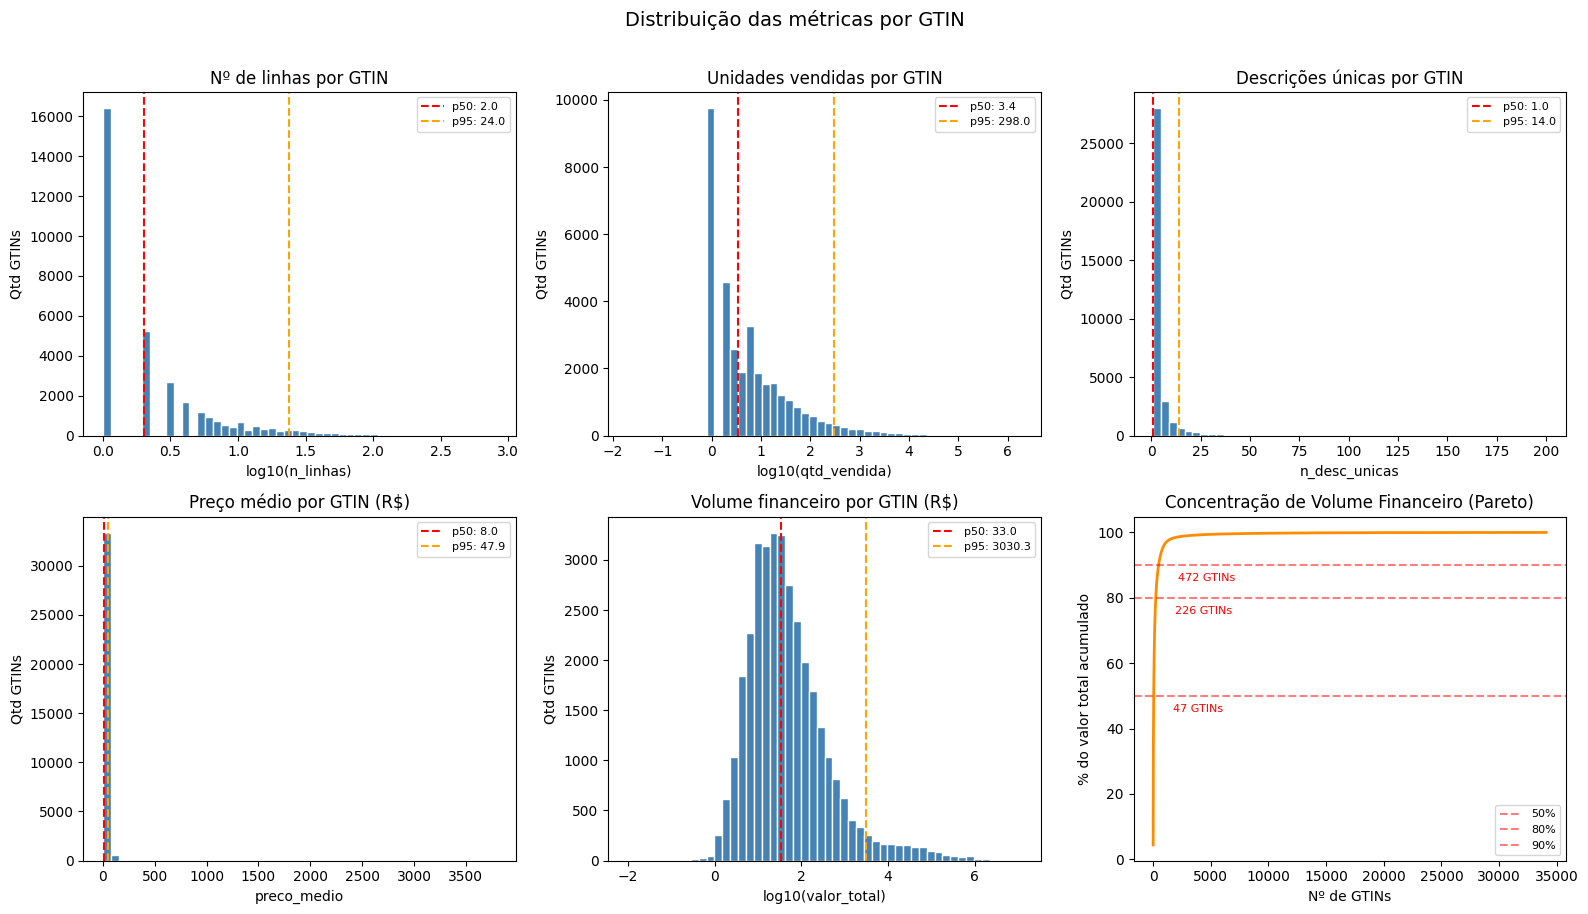

In [84]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

colunas = {
    'n_linhas':      'Nº de linhas por GTIN',
    'qtd_vendida':   'Unidades vendidas por GTIN',
    'n_desc_unicas': 'Descrições únicas por GTIN',
    'preco_medio':   'Preço médio por GTIN (R$)',
    'valor_total':   'Volume financeiro por GTIN (R$)',
}

for ax, (col, titulo) in zip(axes.flat, colunas.items()):
    dados = freq_gtin[col].dropna()

    # escala log para colunas com cauda longa
    usar_log = col in ['n_linhas', 'qtd_vendida', 'valor_total']
    if usar_log:
        dados = dados[dados > 0]
        ax.hist(np.log10(dados), bins=50, color='steelblue', edgecolor='white')
        ax.set_xlabel(f'log10({col})')
    else:
        ax.hist(dados, bins=50, color='steelblue', edgecolor='white')
        ax.set_xlabel(col)

    p50 = dados.median()
    p95 = dados.quantile(0.95)
    ax.axvline(np.log10(p50) if usar_log else p50, color='red',    linestyle='--', label=f'p50: {p50:.1f}')
    ax.axvline(np.log10(p95) if usar_log else p95, color='orange', linestyle='--', label=f'p95: {p95:.1f}')
    ax.set_title(titulo)
    ax.set_ylabel('Qtd GTINs')
    ax.legend(fontsize=8)

# último subplot: concentração de valor (Pareto financeiro)
ax = axes.flat[5]
valor_ord = freq_gtin['valor_total'].dropna().sort_values(ascending=False).reset_index(drop=True)
pct_acum  = valor_ord.cumsum() / valor_ord.sum() * 100
ax.plot(range(1, len(pct_acum) + 1), pct_acum, color='darkorange', linewidth=2)
for pct in [50, 80, 90]:
    ax.axhline(pct, color='red', linestyle='--', alpha=0.5, label=f'{pct}%')
    n = (pct_acum <= pct).sum() + 1
    ax.annotate(f'{n} GTINs', xy=(n, pct), xytext=(n + len(pct_acum)*0.05, pct - 5),
                fontsize=8, color='red')
ax.set_title('Concentração de Volume Financeiro (Pareto)')
ax.set_xlabel('Nº de GTINs')
ax.set_ylabel('% do valor total acumulado')
ax.legend(fontsize=8)

plt.suptitle('Distribuição das métricas por GTIN', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


In [85]:
df_789['ncm'] = df_789['ncm'].astype(str).str.zfill(8)

n_ncm = df_789['ncm'].nunique()
print(f"NCMs distintos na base: {n_ncm:,}")

top_ncm = (
    df_789.groupby('ncm')
    .agg(
        n_linhas   = pd.NamedAgg(column='des_item', aggfunc='count'),
        n_gtins    = pd.NamedAgg(column='gtin',     aggfunc='nunique'),
        n_desc     = pd.NamedAgg(column='des_item_norm', aggfunc='nunique'),
    )
    .sort_values('n_linhas', ascending=False)
    .reset_index()
)

top_ncm['pct_linhas'] = top_ncm['n_linhas'] / len(df_789) * 100
top_ncm['pct_acumulada'] = top_ncm['pct_linhas'].cumsum()

print(f"\nTop 20 NCMs mais frequentes:")
print(top_ncm.head(20).to_string(index=False))


NCMs distintos na base: 1,029

Top 20 NCMs mais frequentes:
     ncm  n_linhas  n_gtins  n_desc  pct_linhas  pct_acumulada
04032000     10313     1242    6254      4.7937         4.7937
17049020      9994     1870    7172      4.6455         9.4392
18069000      9664     1199    4763      4.4921        13.9313
04039000      6583      952    4225      3.0599        16.9912
09012100      5595      532    2813      2.6007        19.5919
16010000      5065      717    3124      2.3543        21.9462
15171000      4989      147    1947      2.3190        24.2652
18063210      4953      575    2160      2.3023        26.5675
04061090      4265      504    2467      1.9825        28.5500
19053100      4189     1062    3570      1.9471        30.4971
01012900      4100     2672    3046      1.9058        32.4029
04022110      3986      362    2202      1.8528        34.2557
22021000      2560      418    2013      1.1900        35.4457
01019000      2554     1936    2123      1.1872        36.

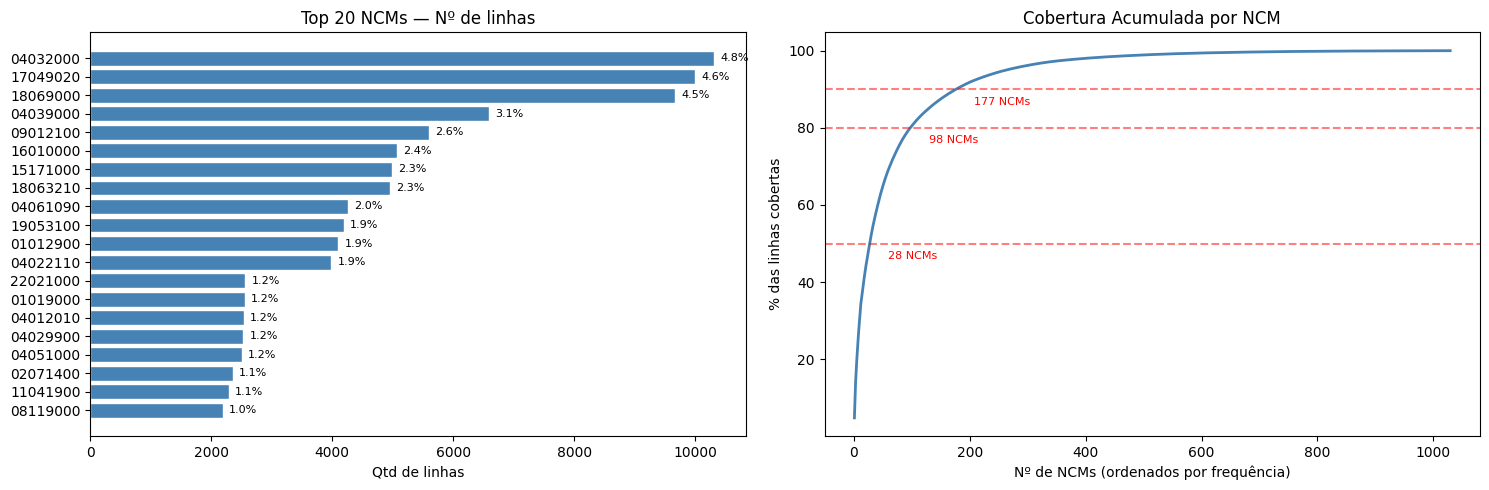

In [86]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Top 20 NCMs por nº de linhas
top20 = top_ncm.head(20)
axes[0].barh(top20['ncm'][::-1], top20['n_linhas'][::-1], color='steelblue', edgecolor='white')
axes[0].set_title('Top 20 NCMs — Nº de linhas')
axes[0].set_xlabel('Qtd de linhas')
for i, (n, pct) in enumerate(zip(top20['n_linhas'][::-1], top20['pct_linhas'][::-1])):
    axes[0].text(n + top20['n_linhas'].max() * 0.01, i, f'{pct:.1f}%', va='center', fontsize=8)

# Pareto de cobertura acumulada
axes[1].plot(range(1, len(top_ncm) + 1), top_ncm['pct_acumulada'],
             color='steelblue', linewidth=2)
for pct in [50, 80, 90]:
    n = (top_ncm['pct_acumulada'] <= pct).sum() + 1
    axes[1].axhline(pct, color='red', linestyle='--', alpha=0.5)
    axes[1].annotate(f'{n} NCMs', xy=(n, pct), xytext=(n + len(top_ncm)*0.03, pct - 4),
                     fontsize=8, color='red')
axes[1].set_title('Cobertura Acumulada por NCM')
axes[1].set_xlabel('Nº de NCMs (ordenados por frequência)')
axes[1].set_ylabel('% das linhas cobertas')

plt.tight_layout()
plt.show()


In [87]:
df_789['capitulo_ncm'] = df_789['ncm'].str[:2]

top_cap = (
    df_789.groupby('capitulo_ncm')
    .agg(
        n_linhas = pd.NamedAgg(column='des_item', aggfunc='count'),
        n_gtins  = pd.NamedAgg(column='gtin',     aggfunc='nunique'),
        n_desc   = pd.NamedAgg(column='des_item_norm', aggfunc='nunique'),
    )
    .sort_values('n_linhas', ascending=False)
    .reset_index()
)

top_cap['pct_linhas']    = top_cap['n_linhas'] / len(df_789) * 100
top_cap['pct_acumulada'] = top_cap['pct_linhas'].cumsum()

print(f"Capítulos NCM distintos: {len(top_cap)}")
print(top_cap.head(20).to_string(index=False))


Capítulos NCM distintos: 26
capitulo_ncm  n_linhas  n_gtins  n_desc  pct_linhas  pct_acumulada
          04     43659     4166   23839     20.2938        20.2938
          18     18045     2121    8702      8.3878        28.6815
          17     17372     3127   11156      8.0749        36.7565
          03     15134     3085    6228      7.0347        43.7911
          16     13984     1567    8666      6.5001        50.2912
          19     12047     3610   10416      5.5997        55.8910
          01     11989     6577    9237      5.5728        61.4637
          11     11528     1285    5610      5.3585        66.8222
          09     10165     2009    5883      4.7249        71.5472
          02      9264     1599    5746      4.3061        75.8533
          15      8641      684    3648      4.0165        79.8698
          10      7363     1321    4071      3.4225        83.2924
          22      6461     1548    5243      3.0032        86.2956
          21      6365     2680   

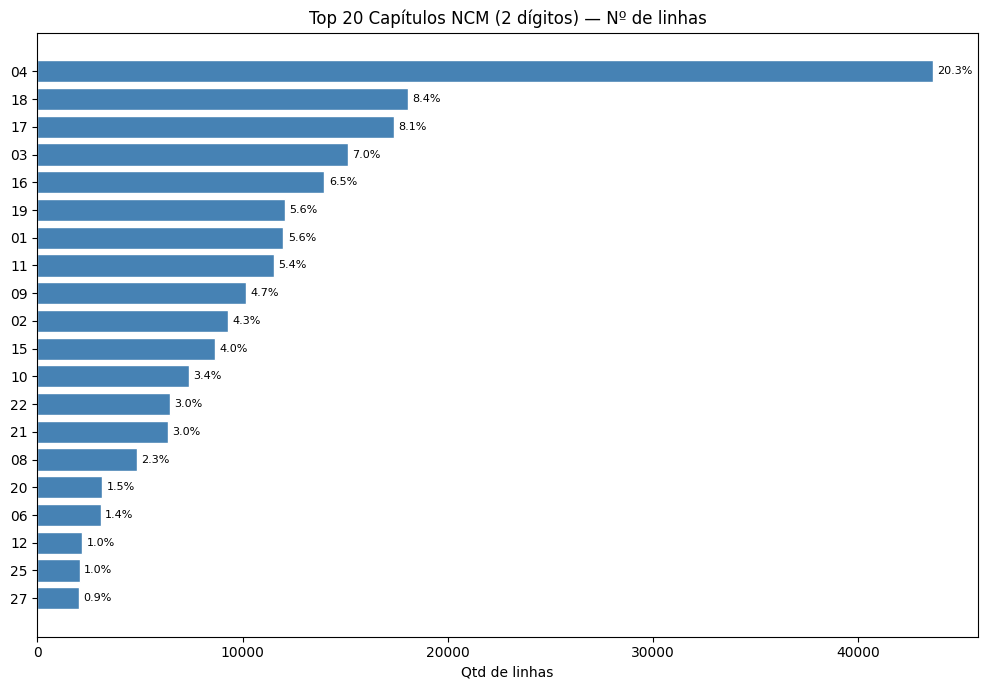

In [88]:
top20_cap = top_cap.head(20)

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(top20_cap['capitulo_ncm'][::-1], top20_cap['n_linhas'][::-1],
               color='steelblue', edgecolor='white')
ax.set_title('Top 20 Capítulos NCM (2 dígitos) — Nº de linhas')
ax.set_xlabel('Qtd de linhas')
for i, (n, pct) in enumerate(zip(top20_cap['n_linhas'][::-1], top20_cap['pct_linhas'][::-1])):
    ax.text(n + top20_cap['n_linhas'].max() * 0.005, i, f'{pct:.1f}%', va='center', fontsize=8)

plt.tight_layout()
plt.show()


In [89]:
df_789['valor_total_linha'] = (
    pd.to_numeric(df_789['valor_unit_liq'], errors='coerce') *
    pd.to_numeric(df_789['qtd_geral_item'], errors='coerce')
)

top_cap = (
    df_789.groupby('capitulo_ncm')
    .agg(
        n_linhas     = pd.NamedAgg(column='des_item',          aggfunc='count'),
        n_gtins      = pd.NamedAgg(column='gtin',              aggfunc='nunique'),
        qtd_vendida  = pd.NamedAgg(column='qtd_geral_item',    aggfunc='sum'),
        valor_total  = pd.NamedAgg(column='valor_total_linha', aggfunc='sum'),
        preco_medio  = pd.NamedAgg(column='valor_unit_liq',    aggfunc='mean'),
    )
    .sort_values('valor_total', ascending=False)
    .reset_index()
)

total_valor = top_cap['valor_total'].sum()
total_qtd   = top_cap['qtd_vendida'].sum()

top_cap['pct_linhas']  = top_cap['n_linhas']    / len(df_789)          * 100
top_cap['pct_valor']   = top_cap['valor_total']  / total_valor          * 100
top_cap['pct_qtd']     = top_cap['qtd_vendida']  / total_qtd            * 100

print(top_cap.head(20).to_string(index=False))


capitulo_ncm  n_linhas  n_gtins  qtd_vendida    valor_total  preco_medio  pct_linhas  pct_valor  pct_qtd
          02      9264     1599 7553780.8334 126483373.6463      19.9492      4.3061    52.8303  49.3565
          16     13984     1567 1668269.3652  30945783.6324      12.4963      6.5001    12.9256  10.9005
          04     43659     4166  843326.5036  27448871.0218      10.8592     20.2938    11.4650   5.5103
          05      1412      321 1168671.2512  14125723.8623      13.1963      0.6563     5.9001   7.6361
          27      2030      659 2152771.1400  13277966.4428      38.1584      0.9436     5.5460  14.0662
          03     15134     3085  504406.9672  11835651.2050      28.3118      7.0347     4.9436   3.2958
          08      4859     1183  193523.1252   3037992.7468       7.7726      2.2586     1.2689   1.2645
          21      6365     2680   46834.2404   1845804.3701      11.5844      2.9586     0.7710   0.3060
          18     18045     2121   67501.0971   1632761.

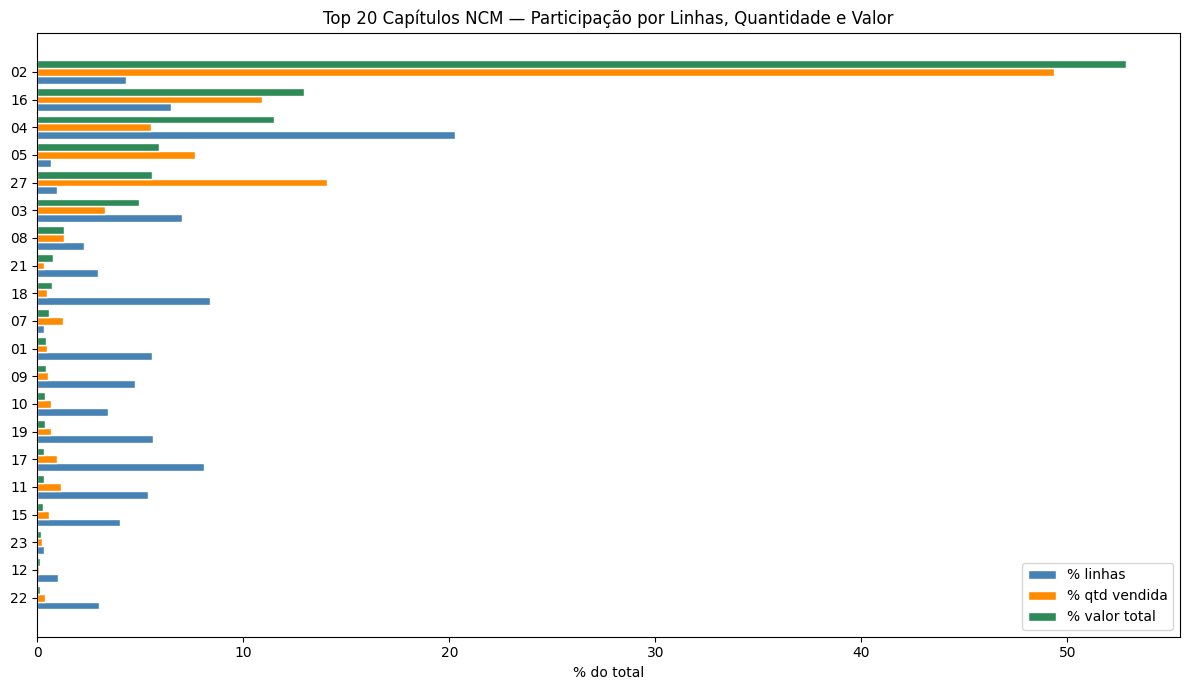

In [90]:
top20_cap = top_cap.head(20)
categorias = top20_cap['capitulo_ncm'][::-1]
x = np.arange(len(categorias))
w = 0.28

fig, ax = plt.subplots(figsize=(12, 7))
ax.barh(x - w, top20_cap['pct_linhas'][::-1], w, label='% linhas',   color='steelblue',  edgecolor='white')
ax.barh(x,     top20_cap['pct_qtd'][::-1],    w, label='% qtd vendida', color='darkorange', edgecolor='white')
ax.barh(x + w, top20_cap['pct_valor'][::-1],  w, label='% valor total', color='seagreen',   edgecolor='white')

ax.set_yticks(x)
ax.set_yticklabels(categorias)
ax.set_xlabel('% do total')
ax.set_title('Top 20 Capítulos NCM — Participação por Linhas, Quantidade e Valor')
ax.legend()
plt.tight_layout()
plt.show()
